# Exercise 004

<a href="https://colab.research.google.com/github/FAIRChemistry/PythonProgramming2025/blob/master/exercises/Exercise004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Please execute this cell to download the necessary data
!wget https://github.com/JR-1991/PythonProgramming2025/raw/master/data/gc_len_data.csv

--2026-05-11 13:36:57--  https://github.com/JR-1991/PythonProgramming2025/raw/master/data/gc_len_data.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/JR-1991/PythonProgramming2025/master/data/gc_len_data.csv [following]
--2026-05-11 13:36:58--  https://raw.githubusercontent.com/JR-1991/PythonProgramming2025/master/data/gc_len_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3663624 (3.5M) [text/plain]
Saving to: ‘gc_len_data.csv’

gc_len_data.csv     100%[===================>]   3.49M  --.-KB/s    in 0.02s   

2026-05-11 13:36:59 (148 MB/s) - ‘gc_len_data.csv’ saved [3663624/3663

In [2]:
# Please execute this cell to install the necessary packages
%pip install seaborn matplotlib pandas scikit-learn

## Visualisation of Distributions #1

Read the CSV file `gc_len_data.csv` using the Pandas method `pd.read_csv(path)` and store the result in `DataFrame` in variable `df`. Now use `seaborn` or `matplotlib` to visualize the distribution of all seqeunce lengths found in column `lens`.

**Tips**

> * Importing a package is done via `import package` where package is substituted with the name of the package you want to import. You can also rename a package by using``import package as renamed` where renamed is the new with which you can use the pckage.
> * By convention, `pandas` is always imported as `pd` and `seaborn` as `sns`
> Seaborn allows you to directly use a Pandas `DataFrame` object (stored in variable `df`). In the following is a usage example:

**Example**

Please refer to our [notes](https://jr-1991.github.io/PythonProgrammingBio24/notes/Seminar_004/) for an in-depth example.

```python
# Seaborn - We pass in the data and specify which column to use
sns.countplot(x="a_column", data=df)
```


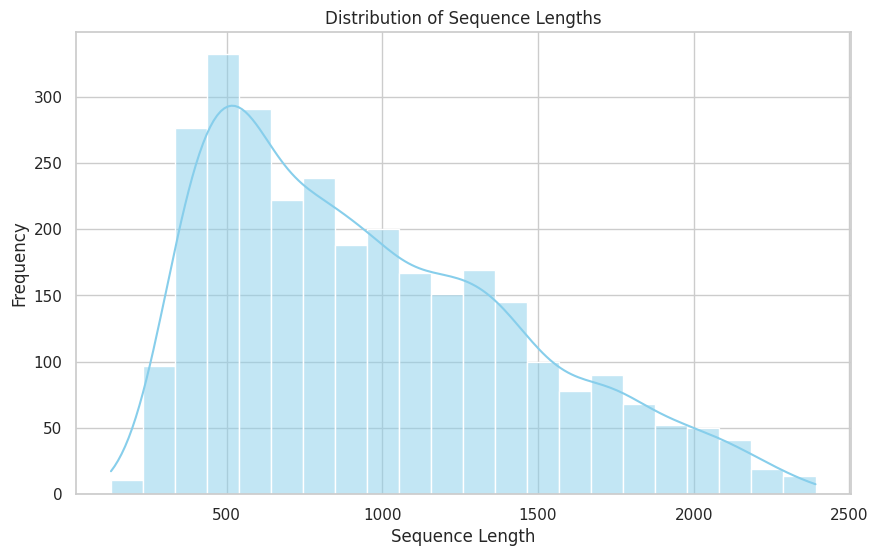

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Read the CSV file
df = pd.read_csv('gc_len_data.csv')

# 2. Set the visual style (optional but looks nice!)
sns.set_theme(style="whitegrid")

# 3. Visualize the distribution of sequence lengths
# histplot is the standard for showing distributions
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='lens', kde=True, color='skyblue')

# 4. Add labels and title for clarity
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')

# 5. Show the plot
plt.show()

### Coloration by class

Repeat the visualization, but now color the distribution in relation to the organism. Which conclusions can you gather from the new plot?

**Tips**

> * Some methods found in Seaborns have an argument with which you can specifiy to colour by a specific column. These can be categorical or numerical.
> * Use the argument `multiple` to specifiy how to handle multiple categories in Seaborn's `histplot` or `kdeplot`. See the [documentation](https://seaborn.pydata.org/api.html) to learn more.

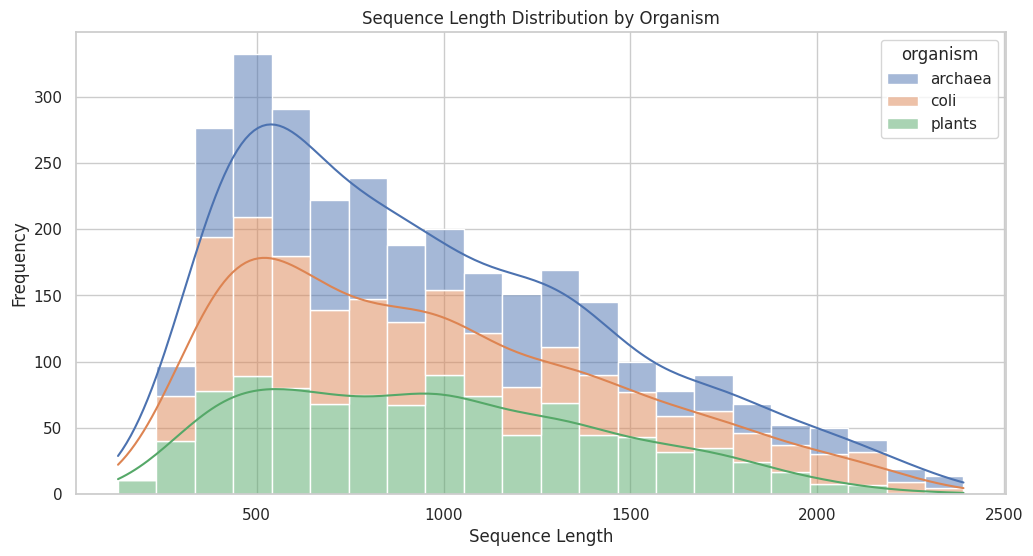

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('gc_len_data.csv')

# Create the visualization
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='lens',
    hue='organism',
    multiple='stack',  # Stacks the distributions to see total and individual counts
    kde=True           # Adds the density curve for each organism
)

plt.title('Sequence Length Distribution by Organism')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.show()

## Visualisation of Distributions #2

Repeat the first exercise now for the gc content using the column `gc`. Can you detect a trend?

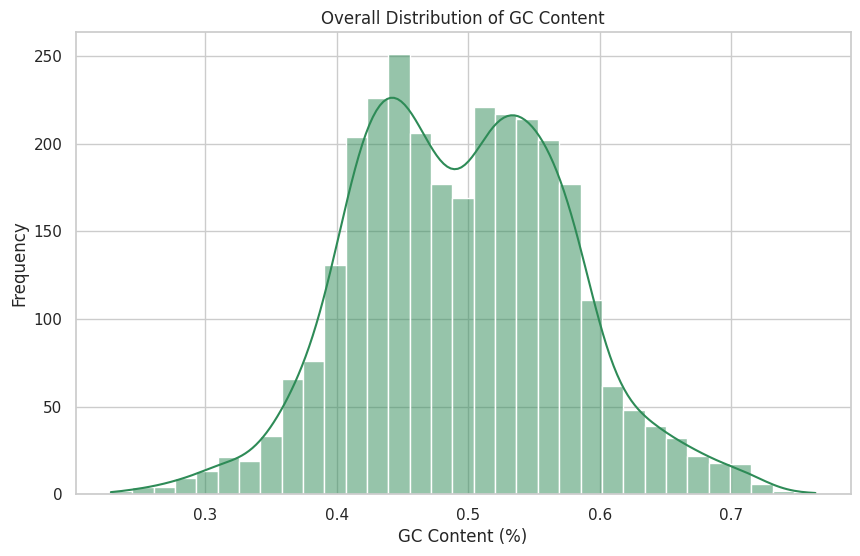

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('gc_len_data.csv')

# Plot overall GC distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='gc', kde=True, color='seagreen')

plt.title('Overall Distribution of GC Content')
plt.xlabel('GC Content (%)')
plt.ylabel('Frequency')
plt.show()

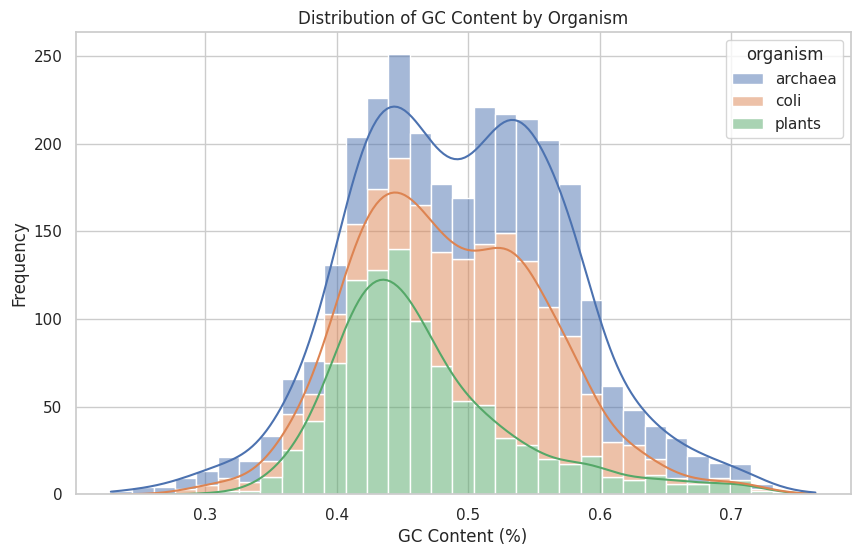

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('gc_len_data.csv')

# Plot GC distribution colored by organism
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='gc', hue='organism', multiple='stack', kde=True)

plt.title('Distribution of GC Content by Organism')
plt.xlabel('GC Content (%)')
plt.ylabel('Frequency')
plt.show()

## Visualisation of bivariate data

In many of our applications and experiments, we want to understand how two features are related to each other. For example, we might want to examine how two variables are correlated in order to develop a hypothesis. In addition to using a quantitative measure like the "R-Squared" value, it can be helpful to create a graph that displays the relationship between the two variables.

Calculate the Correlation Matrix of dataset `df` and print the result. Now visualize both columns `gc` and `lens` in a single plot.

**Tips**

> * The example [gallery](https://seaborn.pydata.org/examples/index.html) of Seaborn can be very inspiring!
> * Pandas can calculate a lot of statistic too. See [here](https://pandas.pydata.org/docs/getting_started/intro_tutorials/06_calculate_statistics.html#) and [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)

Correlation Matrix:
            gc      lens
gc    1.000000 -0.073403
lens -0.073403  1.000000


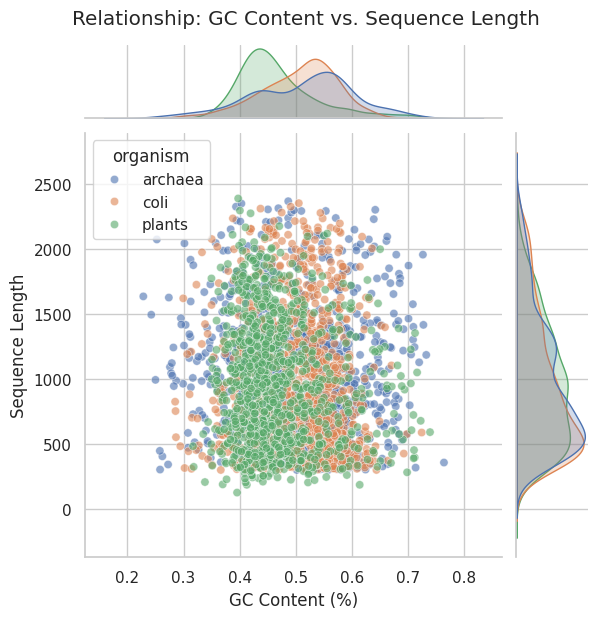

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Read the data
df = pd.read_csv('gc_len_data.csv')

# 2. Calculate the Correlation Matrix
# We select only the numerical columns to avoid errors
corr_matrix = df[['gc', 'lens']].corr()
print("Correlation Matrix:")
print(corr_matrix)

# 3. Visualize the relationship
sns.set_theme(style="whitegrid")

# sns.jointplot creates a scatter plot with marginal histograms
g = sns.jointplot(
    data=df,
    x='gc',
    y='lens',
    hue='organism', # Optional: helps see if trends are species-specific
    alpha=0.6       # Transparency helps if points overlap
)

# Adding titles and labels
g.fig.suptitle('Relationship: GC Content vs. Sequence Length', y=1.03)
g.set_axis_labels('GC Content (%)', 'Sequence Length')

plt.show()

## Multidimensional data

It's not uncommon for data to have more columns than we can easily comprehend in our three-dimensional world. In these cases, we can use techniques like dimensionality reduction and visualization to help us understand the data better. One of the most popular methods for dimensionality reduction is called [Principle Component Analysis](https://en.wikipedia.org/wiki/Principal_component_analysis) (PCA). This statistical technique helps us identify the components that explain most of the variation in the data.

To use PCA, we need to utilize a module called `scikit-learn`, which also contains many other machine learning algorithms. Since the `df` dataset comprises not only `gc` and `lens` but also individual codon usage, we can use PCA to demonstrate that our classes are more or less distinctive. To apply PCA to the dataset, please make use of the provided `pca` function.

In [8]:
# Execute this cell to use the function

import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler


def pca(data: pd.DataFrame) -> pd.DataFrame:
    """Takes a DataFrame and calculates the first two principle components

    Args:
        data (pd.DataFrame): The data used to gather the PCs

    Returns:
        pd.DataFrame: The resulting PCA data
    """

    scaler = MinMaxScaler()
    data = scaler.fit_transform(data.select_dtypes(include="number"))

    pcs = PCA(n_components=2).fit_transform(data)

    return pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1]})

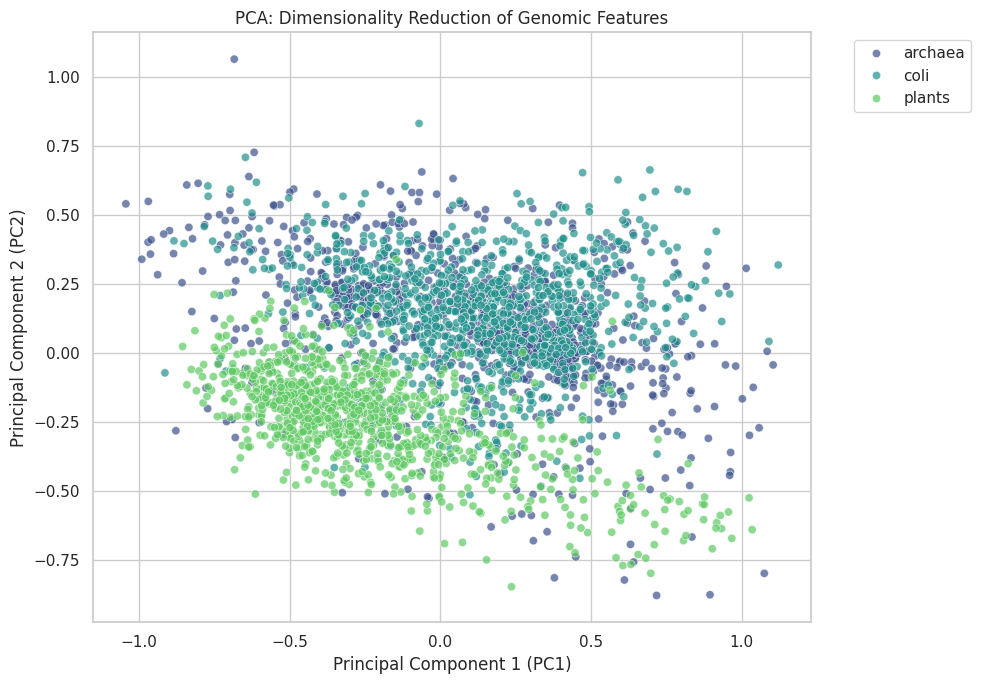

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('gc_len_data.csv')

# 2. Apply the PCA function (provided in your prompt)
# This uses MinMaxScaler and PCA(n_components=2)
df_pca = pca(df)

# 3. Re-attach the 'organism' column for coloring the plot
df_pca['organism'] = df['organism']

# 4. Visualize the results
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='organism',
    palette='viridis',
    alpha=0.7
)

plt.title('PCA: Dimensionality Reduction of Genomic Features')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()